<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

In [3]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment1/Data1.csv', encoding='latin1')

Father Education vs Mean Score:


,EDU_FATHER,count,mean,std
0,Ninguno,123,156.634146,23.188560
1,Incomplete primary,735,155.729252,20.942412
2,Complete primary,824,155.195388,22.410767
3,Incomplete Secundary,1091,156.535289,21.736989
4,Complete Secundary,2843,158.785790,22.114288
5,Incomplete technical or technological,277,162.101083,21.881198
6,Complete technique or technology,1194,164.033501,22.165359
7,Incomplete Professional Education,425,166.917647,22.685198
8,Complete professional education,3016,167.765915,23.030089
9,Postgraduate education,1085,176.985253,21.734132



Mother Education vs Mean Score:


,EDU_MOTHER,count,mean,std
0,Ninguno,34,149.705882,27.930139
1,Incomplete primary,541,154.853974,21.636024
2,Complete primary,713,155.336606,22.012293
3,Incomplete Secundary,1056,155.672348,21.928635
4,Complete Secundary,3106,158.470702,21.949597
5,Incomplete technical or technological,341,161.879765,20.744388
6,Complete technique or technology,1495,163.242140,21.943495
7,Incomplete Professional Education,502,166.685259,22.931830
8,Complete professional education,3059,168.845374,22.978321
9,Postgraduate education,997,175.636911,22.119758


/tmp/ipython-input-2292960690.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=father_stats, x='EDU_FATHER', y='mean',palette="pink", order=edu_order)


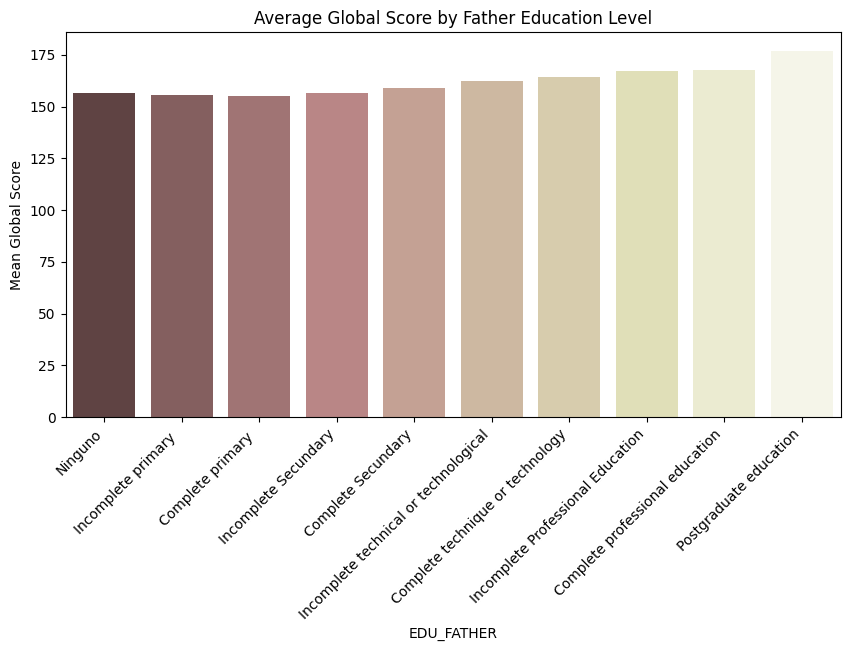

/tmp/ipython-input-2292960690.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mother_stats, x='EDU_MOTHER', y='mean', palette="pink", order=edu_order)


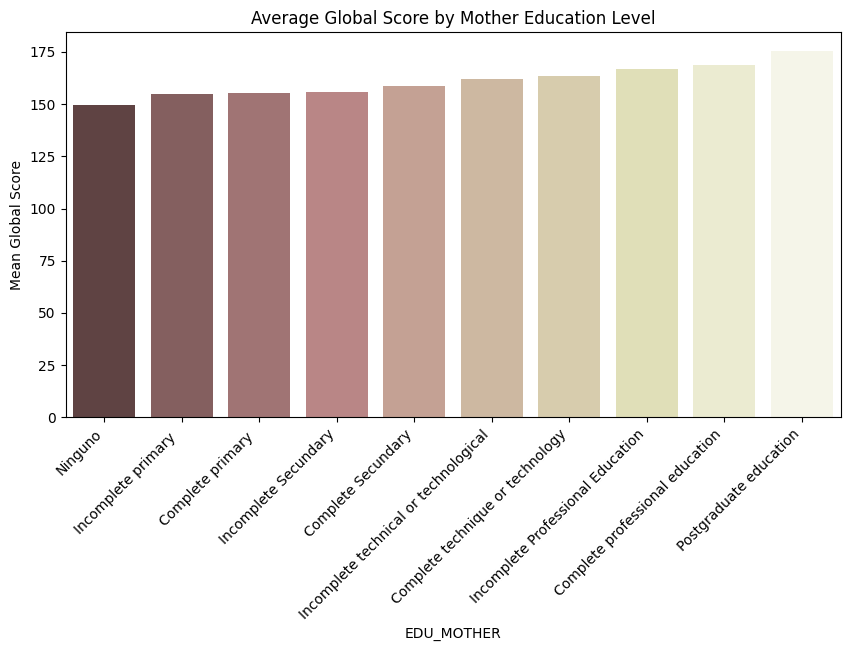

In [5]:
# Parents' education levels
edu_order = [
    'Ninguno','Incomplete primary ', 'Complete primary ', 'Incomplete Secundary',
    'Complete Secundary', 'Incomplete technical or technological',
    'Complete technique or technology', 'Incomplete Professional Education',
    'Complete professional education', 'Postgraduate education'
]
df['EDU_FATHER'] = pd.Categorical(df['EDU_FATHER'], categories=edu_order, ordered=True)
df['EDU_MOTHER'] = pd.Categorical(df['EDU_MOTHER'], categories=edu_order, ordered=True)

# Grouping and aggregating data by father and mother's education
father_stats = df.groupby('EDU_FATHER', observed=False)['G_SC'].agg(['count', 'mean', 'std']).reset_index()
mother_stats = df.groupby('EDU_MOTHER', observed=False)['G_SC'].agg(['count', 'mean', 'std']).reset_index()

# Display results
print("Father Education vs Mean Score:")
display(father_stats)

print("\nMother Education vs Mean Score:")
display(mother_stats)

# Bar plot for father's education
plt.figure(figsize=(10,5))
sns.barplot(data=father_stats, x='EDU_FATHER', y='mean',palette="pink", order=edu_order)
plt.xticks(rotation=45, ha='right') # Adjusted rotation and alignment
plt.title('Average Global Score by Father Education Level')
plt.ylabel('Mean Global Score')
plt.show()

# Bar plot for mother's education
plt.figure(figsize=(10,5))
sns.barplot(data=mother_stats, x='EDU_MOTHER', y='mean', palette="pink", order=edu_order)
plt.xticks(rotation=45, ha='right') # Adjusted rotation and alignment
plt.title('Average Global Score by Mother Education Level')
plt.ylabel('Mean Global Score')
plt.show()

Combined both father and mother:


/tmp/ipython-input-1414912959.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_stats = df.groupby(['EDU_FATHER', 'EDU_MOTHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()


,EDU_FATHER,EDU_MOTHER,mean,std,count
0,Ninguno,Ninguno,147.555556,31.012753,18
1,Ninguno,Incomplete primary,153.692308,20.466984,13
2,Ninguno,Complete primary,154.133333,22.598567,15
3,Ninguno,Incomplete Secundary,158.700000,17.732895,10
4,Ninguno,Complete Secundary,162.206897,19.842918,29
...,...,...,...,...,...
95,Postgraduate education,Incomplete technical or technological,172.928571,18.403446,14
96,Postgraduate education,Complete technique or technology,167.867470,22.322892,83
97,Postgraduate education,Incomplete Professional Education,174.255319,20.268275,47
98,Postgraduate education,Complete professional education,178.566092,21.211266,348


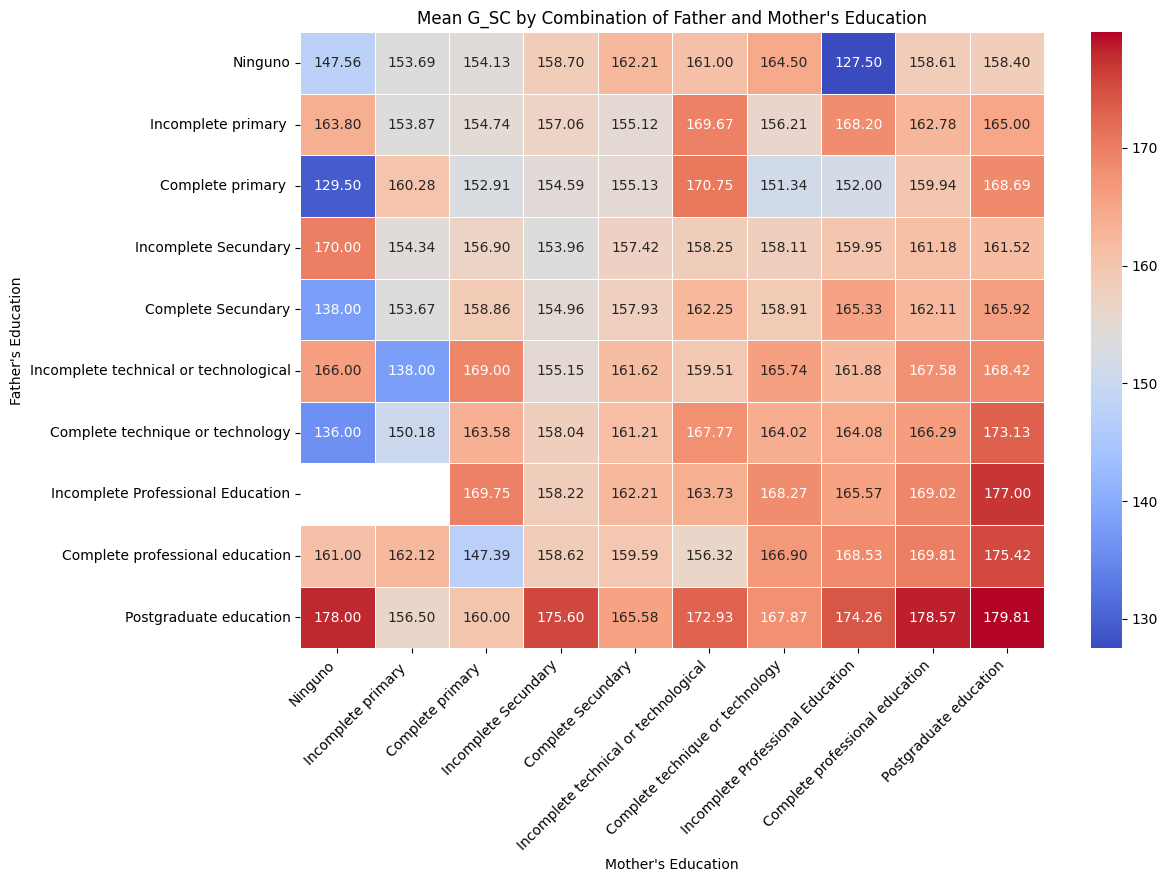

ANOVA p-value: 2.4997879285531146e-212


In [ ]:
#combine
combined_stats = df.groupby(['EDU_FATHER', 'EDU_MOTHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()
print("Combined both father and mother:")
display(combined_stats)
#plot
heatmap_data = combined_stats.pivot(index='EDU_FATHER', columns='EDU_MOTHER', values='mean')
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mean G_SC by Combination of Father and Mother\'s Education')
plt.xlabel('Mother\'s Education')
plt.ylabel('Father\'s Education')
plt.xticks(rotation=45, ha='right')
plt.show()

# Create a new column for the combined education level
df['combined_edu'] = df['EDU_FATHER'].astype(str) + '_' + df['EDU_MOTHER'].astype(str)

# Filter out groups with less than 2 data points for ANOVA
valid_groups_data = [df[df['combined_edu'] == group]['G_SC'].dropna() for group in df['combined_edu'].unique() if len(df[df['combined_edu'] == group]['G_SC'].dropna()) >= 2]

# Perform One-Way ANOVA on valid groups
if valid_groups_data: # Only perform ANOVA if there are valid groups
    anova_result = stats.f_oneway(*valid_groups_data)
    # Print the result
    print(f"ANOVA p-value: {anova_result.pvalue}")
else:
    print("No valid groups with at least 2 data points for ANOVA.")

/tmp/ipython-input-4178147623.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  father_stats = df.groupby(['OCC_FATHER', 'EDU_FATHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()
/tmp/ipython-input-4178147623.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mother_stats = df.groupby(['OCC_MOTHER', 'EDU_MOTHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()


  OCC_FATHER            EDU_FATHER        mean        std  count
0          0               Ninguno  177.000000  26.286879      3
1          0   Incomplete primary   157.741935  20.181192     93
2          0     Complete primary   157.275862  20.658614     29
3          0  Incomplete Secundary  163.565217  22.993727     23
4          0    Complete Secundary  157.444444  24.322227     45
  OCC_MOTHER            EDU_MOTHER        mean        std  count
0          0               Ninguno         NaN        NaN      0
1          0   Incomplete primary   158.835443  20.864908     79
2          0     Complete primary   159.200000  19.312810     40
3          0  Incomplete Secundary  153.500000   6.363961      2
4          0    Complete Secundary         NaN        NaN      0


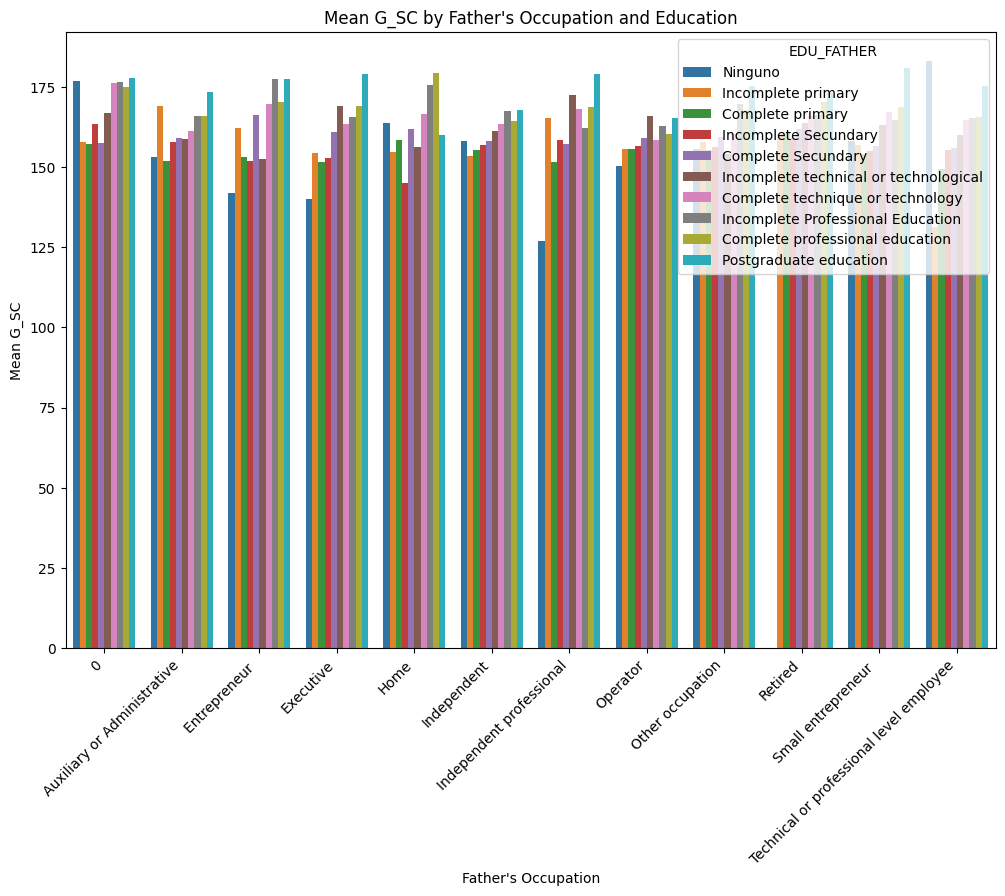

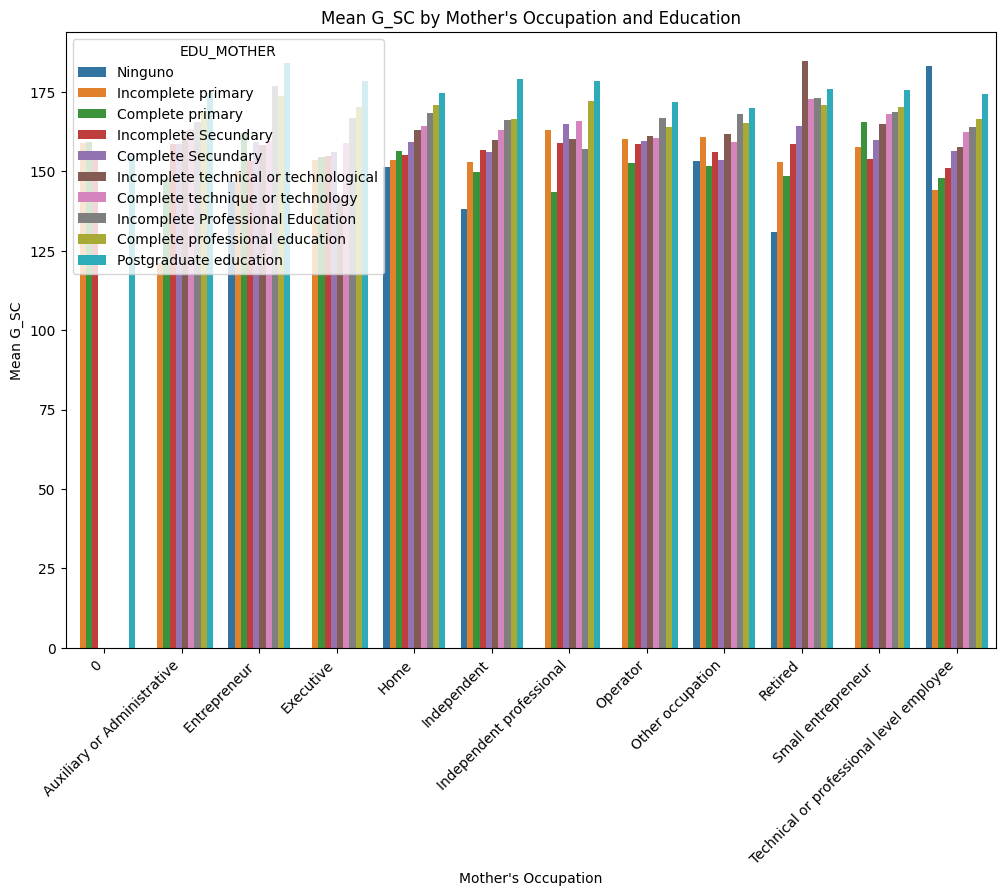

In [ ]:
#Occupation & Education Father
father_stats = df.groupby(['OCC_FATHER', 'EDU_FATHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()

#Occupation & Education Mother
mother_stats = df.groupby(['OCC_MOTHER', 'EDU_MOTHER'])['G_SC'].agg(['mean', 'std', 'count']).reset_index()
print(father_stats.head())
print(mother_stats.head())
# Plot for father's occupation and education
plt.figure(figsize=(12,8))
sns.barplot(x='OCC_FATHER', y='mean', hue='EDU_FATHER', data=father_stats)
plt.xticks(rotation=45, ha='right')
plt.title('Mean G_SC by Father\'s Occupation and Education')
plt.ylabel('Mean G_SC')
plt.xlabel('Father\'s Occupation')
plt.show()
# Plot for mother's occupation and education
plt.figure(figsize=(12,8))
sns.barplot(x='OCC_MOTHER', y='mean', hue='EDU_MOTHER',data=mother_stats)
plt.xticks(rotation=45, ha='right')
plt.title('Mean G_SC by Mother\'s Occupation and Education')
plt.ylabel('Mean G_SC')
plt.xlabel('Mother\'s Occupation')
plt.show()

Stratum Performance Analysis:
      STRATUM  count        mean        std
0          0     14  154.000000  21.321712
1  Stratum 1   1709  152.352838  21.937401
2  Stratum 2   4029  158.199305  22.278029
3  Stratum 3   4045  163.815328  21.693970
4  Stratum 4   1578  172.002535  21.469094
5  Stratum 5    633  177.387046  21.543236
6  Stratum 6    403  181.511166  21.879401


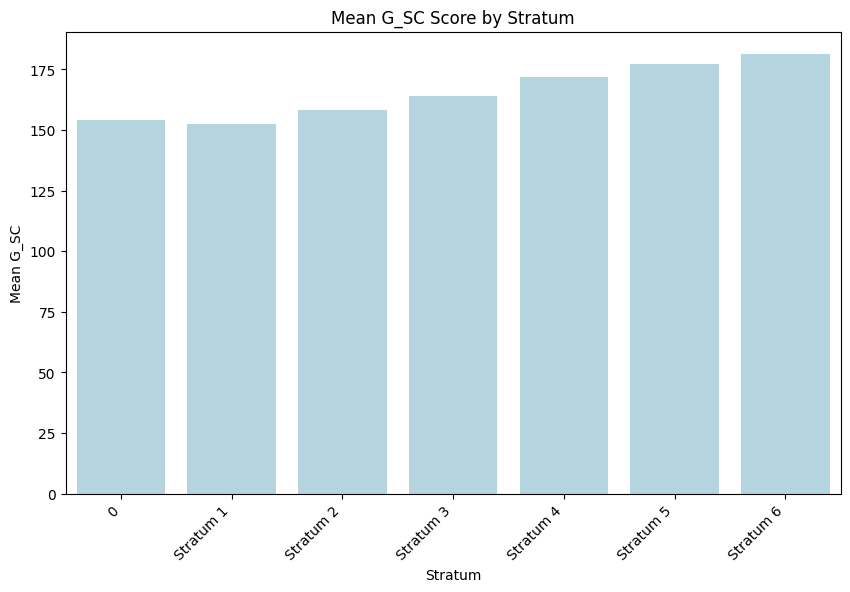

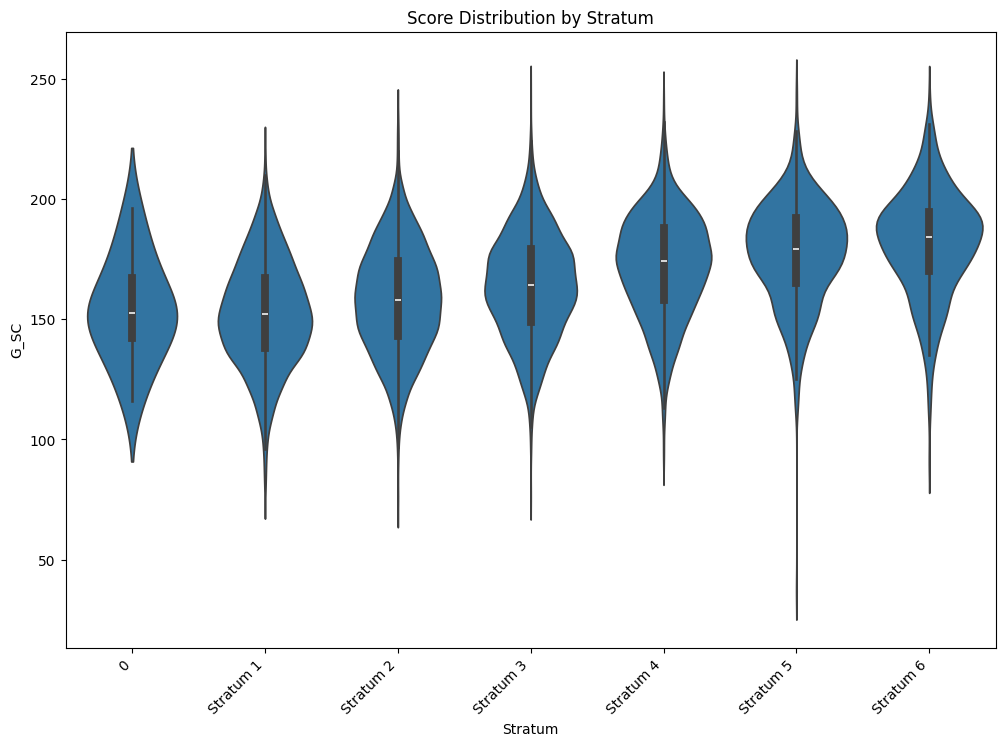


ANOVA test for STRATUM and G_SC:
F-statistic: 238.76914026732305
P-value: 8.289596738433048e-290


In [6]:
# STRATUM
stratum_stats = df.groupby('STRATUM')['G_SC'].agg(['count', 'mean', 'std']).reset_index()
print("Stratum Performance Analysis:\n", stratum_stats)
# Bar plot to visualize mean G_SC score by stratum
plt.figure(figsize=(10,6))
sns.barplot(x='STRATUM', y='mean',color="lightblue", data=stratum_stats)
plt.xticks(rotation=45, ha='right')
plt.title('Mean G_SC Score by Stratum')
plt.ylabel('Mean G_SC')
plt.xlabel('Stratum')
plt.show()
# Violin plot to show the distribution of G_SC by stratum
plt.figure(figsize=(12,8))
# Define the desired order for the x-axis
stratum_order = ['0', 'Stratum 1', 'Stratum 2', 'Stratum 3', 'Stratum 4', 'Stratum 5', 'Stratum 6']
sns.violinplot(x='STRATUM', y='G_SC', data=df, order=stratum_order)
plt.xticks(rotation=45, ha='right')
plt.title('Score Distribution by Stratum')
plt.xlabel('Stratum')
plt.ylabel('G_SC')
plt.show()
#ANOVA test
# Prepare data for ANOVA
stratum_groups = df.groupby('STRATUM')['G_SC'].apply(list)

# Perform One-Way ANOVA
anova_result = stats.f_oneway(*stratum_groups)

# Print the result
print(f"\nANOVA test for STRATUM and G_SC:")
print(f"F-statistic: {anova_result.statistic}")
print(f"P-value: {anova_result.pvalue}")

Gender Performance Analysis:
   GENDER  count        mean        std
0      F   5043  161.278207  22.332939
1      M   7368  163.690825  23.582616


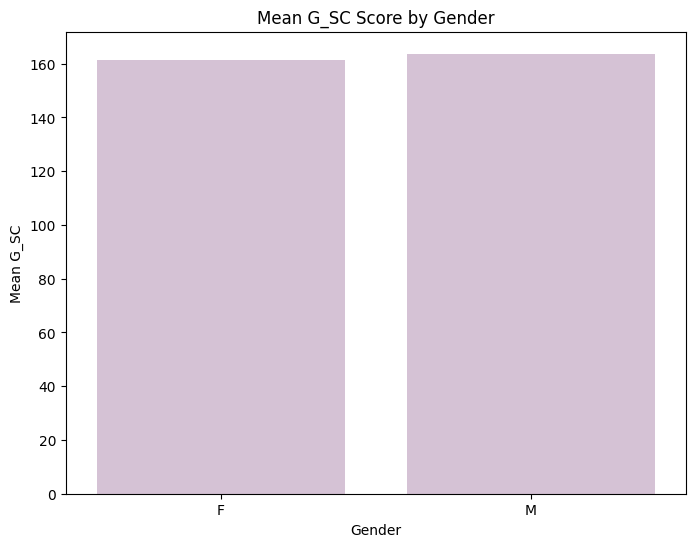

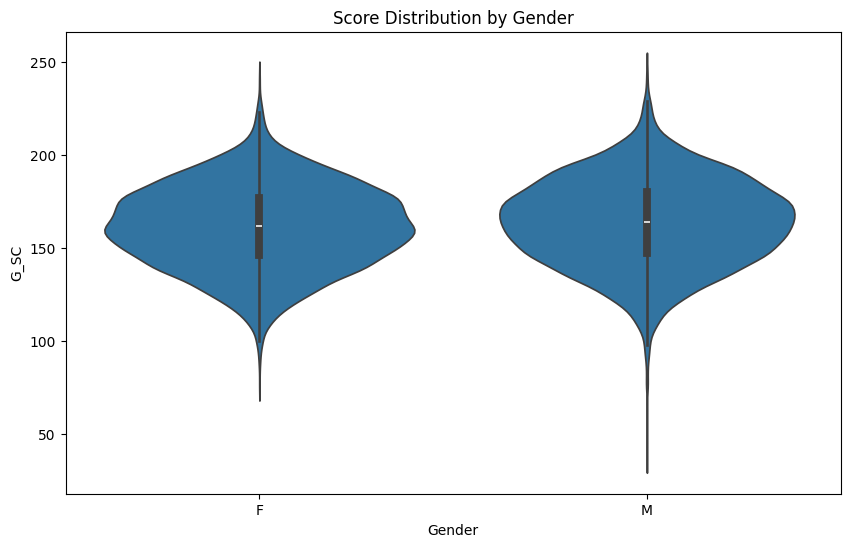

T-statistic: 5.718892966272757
P-value: 1.0969436255680257e-08


In [ ]:
#Gender
gender_stats = df.groupby('GENDER')['G_SC'].agg(['count', 'mean', 'std']).reset_index()
print("Gender Performance Analysis:\n", gender_stats)
# Bar plot to visualize mean G_SC score by gender
plt.figure(figsize=(8,6))
sns.barplot(x='GENDER', y='mean',color='thistle', data=gender_stats)
plt.title('Mean G_SC Score by Gender')
plt.ylabel('Mean G_SC')
plt.xlabel('Gender')
plt.show()
# Violin plot to show the distribution and density of G_SC by gender
plt.figure(figsize=(10,6))
sns.violinplot(x='GENDER', y='G_SC', data=df)
plt.title('Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('G_SC')
plt.show()
# Perform a t-test to compare the mean G_SC scores between males and females
male_scores = df[df['GENDER'] == 'M']['G_SC'].dropna()
female_scores = df[df['GENDER'] == 'F']['G_SC'].dropna()

t_stat, p_value = stats.ttest_ind(male_scores, female_scores)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")